##  **Automatic Image Captioning with Model Benchmarking and Robustness Analysis**

### **Part B: Studying Performance Change Under Image Occlusion**
#### **Section 2: Effect of Image Occlusion on Custom Model**

This notebook tests the robustness of a custom-trained image captioning model when subjected to varying degrees of image occlusion. Here, we generate captions on occluded images using the custom model and evaluate them using the metrics ROUGE-L, BLEU Score, METEOR Score. This analysis helps us understand the model's strengths and weaknesses, and informs potential strategies for improving its resilience to noisy or incomplete visual inputs.

In [1]:
'''
    Installing dependencies
'''
!pip install nltk
!pip install rouge
!pip install bert-score
!pip install evaluate
!pip install rouge_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# import required libraries

import os
import nltk
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import evaluate

from PIL import Image
from torch.utils.data import DataLoader
from transformers import ViTModel, AutoModelForCausalLM, AutoTokenizer, ViTImageProcessor
from transformers import AutoProcessor, AutoModelForVision2Seq
from torch.optim import AdamW
from tqdm import tqdm
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from rouge import Rouge
from bert_score import score

In [4]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### **Preparing Dataset**

In [ ]:
# Same class from Part A

class CaptionsDataset(torch.utils.data.Dataset):

    def __init__(self, csv_file, img_folder, tokenizer=None, feature_extractor=None, processor=None, max_length=50, raw_mode=False):
        self.data = pd.read_csv(csv_file)
        self.img_folder = img_folder
        self.feature_extractor = feature_extractor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.raw_mode = raw_mode

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_folder, self.data.iloc[idx]["filename"])
        caption = self.data.iloc[idx]["caption"]
        image = Image.open(img_path).convert("RGB")
        model_input = {}

        if self.raw_mode:
            return img_path, caption
        else:

            pixel_values = self.feature_extractor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)
            tokenized_caption = self.tokenizer(
                caption,
                padding="max_length",
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt"
            )

            model_input["pixel_values"] = pixel_values
            model_input["input_ids"] = tokenized_caption.input_ids.squeeze(0)
            model_input["attention_mask"] = tokenized_caption.attention_mask.squeeze(0)

        model_input["caption"] = caption
        model_input["img_paths"] = img_path

        return model_input


In [ ]:
def collate_fn(batch):
    if isinstance(batch[0], tuple):
        img_paths, captions = zip(*batch)
        return {
            'img_paths': list(img_paths),
            'captions': list(captions)
        }

    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    captions = [item['caption'] for item in batch]
    img_paths = [item['img_paths'] for item in batch]

    return {
        'pixel_values': pixel_values,
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'captions': captions,
        'img_paths': img_paths
    }


In [ ]:

def get_captioning_loaders(
    root_dir='dataset/custom_captions_dataset',
    train_dir='train',
    val_dir='val',
    test_dir='test',
    train_csv='train.csv',
    val_csv='val.csv',
    test_csv='test.csv',
    batch_size=8,
    collate_fn=None,
    use_processor=False,
    tokenizer_model_id="gpt2",
    extractor_model_id="google/vit-base-patch16-224-in21k"
):
    """
    Returns train, val, test dataloaders
    """

    if use_processor:
        def dataset_factory(csv_file, image_root):
            return CaptionsDataset(
                csv_file=csv_file,
                img_folder=image_root,
                raw_mode=True
            )

    else:
        tokenizer = AutoTokenizer.from_pretrained(tokenizer_model_id)
        feature_extractor = ViTImageProcessor.from_pretrained(extractor_model_id)

        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        def dataset_factory(csv_file, image_root):
            return CaptionsDataset(
                csv_file=csv_file,
                img_folder=image_root,
                tokenizer=tokenizer,
                feature_extractor=feature_extractor,
                raw_mode=True,
            )

    train_path = f"{root_dir}/{train_dir}"
    val_path = f"{root_dir}/{val_dir}"
    test_path = f"{root_dir}/{test_dir}"
    train_csv_path = f"{root_dir}/{train_csv}"
    val_csv_path = f"{root_dir}/{val_csv}"
    test_csv_path = f"{root_dir}/{test_csv}"

    train_dataset = dataset_factory(train_csv_path, train_path)
    val_dataset = dataset_factory(val_csv_path, val_path)
    test_dataset = dataset_factory(test_csv_path, test_path)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    return train_loader, val_loader, test_loader


#### **Custom Model**

- **Model Architecture**: The custom model consists of a Vision Transformer (ViT) for image encoding and a GPT-2 model for caption generation. (as in Part A)
- **Loading Pre-trained Weights**: Pre-trained weights for both ViT and GPT-2 are loaded to initialize the model.
- **Loading Custom Weights**: The model's state dictionary is loaded from a pre-trained `.pt` file, restoring the weights from a previous training session on a custom dataset.
- **Inference**: The model is set to evaluation mode (`model.eval()`) to disable training-specific features like dropout, ensuring consistent and optimized caption generation.

In [ ]:
# load dataloaders

train_loader, val_loader, test_loader = get_captioning_loaders(
    root_dir='/kaggle/input/captioning',
    batch_size=8
)

train_dataset = train_loader.dataset
val_dataset = val_loader.dataset
test_dataset = test_loader.dataset

In [ ]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, vit_model, gpt_model, tokenizer):
        super(ImageCaptioningModel, self).__init__()
        self.vit_model = vit_model
        self.gpt_model = gpt_model
        self.tokenizer = tokenizer
        self.tokenizer.pad_token = self.tokenizer.eos_token

        self.linear_layer = nn.Linear(vit_model.config.hidden_size, gpt_model.config.hidden_size)

        for param in self.vit_model.parameters():
            param.requires_grad = False


    def forward(self, pixel_values, input_ids=None, attention_mask=None, labels=None):
        vit_outputs = self.vit_model(pixel_values=pixel_values)
        image_features = vit_outputs.last_hidden_state

        cls_features = image_features[:, 0]                     # [batch_size, hidden_size]
        projected_features = self.linear_layer(cls_features)    # [batch_size, gpt_hidden_size]
        prefix_embeds = projected_features.unsqueeze(1)         # [batch_size, 1, gpt_hidden_size]

        # print(prefix_embeds.shape)
        # print(input_ids.shape)
        # print(attention_mask.shape)
        # print(labels.shape)

        if input_ids is not None:
            token_embeds = self.gpt_model.transformer.wte(input_ids)
            inputs_embeds = torch.cat([prefix_embeds, token_embeds], dim=1)

            # Adjust attention mask to account for the prefix
            if attention_mask is not None:
                batch_size = attention_mask.shape[0]
                prefix_attention_mask = torch.ones((batch_size, 1), device=attention_mask.device)
                full_attention_mask = torch.cat([prefix_attention_mask, attention_mask], dim=1)
            else:
                full_attention_mask = None

            if labels is not None:

                shifted_labels = torch.full(
                    (input_ids.shape[0], input_ids.shape[1] + 1),
                    -100,
                    dtype=torch.long,
                    device=input_ids.device
                )

                shifted_labels[:, 1:] = input_ids.clone()

                # now send it through GPT
                outputs = self.gpt_model(
                    inputs_embeds=inputs_embeds,
                    attention_mask=full_attention_mask,
                    labels=shifted_labels
                )
            else:
                outputs = self.gpt_model(
                    inputs_embeds=inputs_embeds,
                    attention_mask=full_attention_mask
                )

            return outputs
        else:
            return prefix_embeds

    def generate(self, pixel_values, max_length=50, num_beams=4, early_stopping=True):

        # Encoder = Get image embeddings
        with torch.no_grad():
            vit_outputs = self.vit_model(pixel_values=pixel_values)
            image_features = vit_outputs.last_hidden_state
            cls_features = image_features[:, 0]
            projected_features = self.linear_layer(cls_features)
            prefix_embeds = projected_features.unsqueeze(1)

        # Decoder = Generate caption using GPT with image prefix
        output_ids = self.gpt_model.generate(
            inputs_embeds=prefix_embeds,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=early_stopping,
            no_repeat_ngram_size=2,
            pad_token_id=self.tokenizer.pad_token_id,
            eos_token_id=self.tokenizer.eos_token_id
        )

        captions = [self.tokenizer.decode(output_id, skip_special_tokens=True) for output_id in output_ids]
        return captions

In [ ]:
def compute_metrics(eval_preds, tokenizer):
    metric = evaluate.load("rouge")

    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = preds

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = ["\n".join(nltk.sent_tokenize(pred)) for pred in decoded_preds]
    decoded_labels = ["\n".join(nltk.sent_tokenize(label)) for label in decoded_labels]

    result = metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    result = {k: round(v * 100, 4) for k, v in result.items()}

    prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id) for pred in preds]
    result["gen_len"] = np.mean(prediction_lens)

    return result

In [ ]:
vit_model = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
gpt_model = AutoModelForCausalLM.from_pretrained("gpt2")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
feature_extractor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

In [ ]:
model = ImageCaptioningModel(vit_model, gpt_model, tokenizer)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
def generate_caption_for_image(image_path, model, feature_extractor, device):
    image = Image.open(image_path).convert("RGB")
    pixel_values = feature_extractor(images=image, return_tensors="pt").pixel_values.to(device)

    model.to(device)
    model.eval()

    with torch.no_grad():
        captions = model.generate(pixel_values)

    return captions[0]

In [ ]:
model = ImageCaptioningModel(vit_model, gpt_model, tokenizer)
state_dict = torch.load('/kaggle/input/vitgptcustom/pytorch/default/1/best_captioning_model.pt')
model.load_state_dict(state_dict)

model.to(device)
model.eval()

ImageCaptioningModel(
  (vit_model): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_f

In [ ]:
def display_image_with_caption(image_path, caption):
    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(caption, fontsize=12, wrap=True)
    plt.show()

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


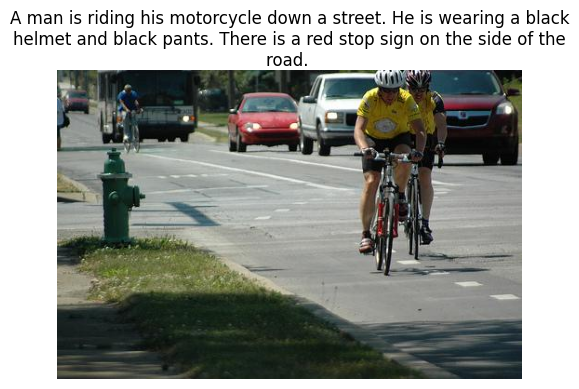

In [ ]:
sample_image_path = "/kaggle/input/captioning/test/test_8.jpg"
caption = generate_caption_for_image(sample_image_path, model, feature_extractor, device)

display_image_with_caption(sample_image_path, caption)

#### **Image Occlusion**

Image occlusion involves dividing the image into patches and masking a percentage of them with black pixels to test model robustness.

- **Patch-based Masking**: The image is divided into a grid of patches, and a specified percentage of these patches are masked (set to black).
- **Varying Occlusion Levels**: The percentage of masked patches is varied to simulate different levels of visual obstruction.
- **Robustness Testing**: By observing how the model's performance changes with increasing occlusion, we can assess its robustness to partial data loss.


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch

def generate_caption(image_np, model, feature_extractor, device):
    image_pil = Image.fromarray(image_np).convert("RGB")
    pixel_values = feature_extractor(images=image_pil, return_tensors="pt").pixel_values.to(device)

    model.to(device)
    model.eval()

    with torch.no_grad():
        captions = model.generate(pixel_values)

    return captions[0]

def occlude_image(image: np.array, mask_percentage: int) -> np.array:
    height, width, channels = image.shape
    patch_size = 16

    num_patches_y = height // patch_size
    num_patches_x = width // patch_size
    total_patches = num_patches_y * num_patches_x

    num_mask = int((mask_percentage / 100.0) * total_patches)

    patch_indices = [(i, j) for i in range(num_patches_y) for j in range(num_patches_x)]
    selected_indices = np.random.choice(len(patch_indices), size=num_mask, replace=False)
    occluded_image = image.copy()

    for idx in selected_indices:
        i, j = patch_indices[idx]
        y_start, y_end = i * patch_size, (i + 1) * patch_size
        x_start, x_end = j * patch_size, (j + 1) * patch_size
        occluded_image[y_start:y_end, x_start:x_end] = 0

    return occluded_image

def visualize_occlusion(original: np.array, occluded: np.array, mask_percentage: int):
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(occluded)
    plt.title(f"Occluded Image ({mask_percentage}%)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

def run_captioning_with_occlusion(image_path, model, feature_extractor, device, mask_percentages=[10, 50, 80]):
    image = Image.open(image_path).convert("RGB")
    img_np = np.array(image)

    results = {}
    for p in mask_percentages:
        occluded = occlude_image(img_np, p)
        # visualize_occlusion(img_np, occluded, p)
        caption = generate_caption(occluded, model, feature_extractor, device)
        results[p] = caption

    return results


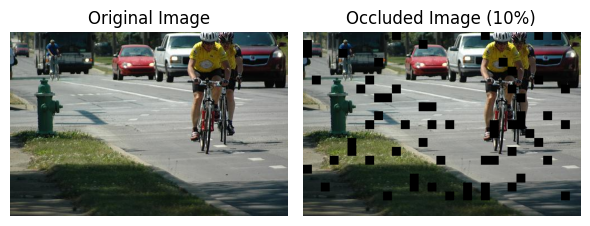

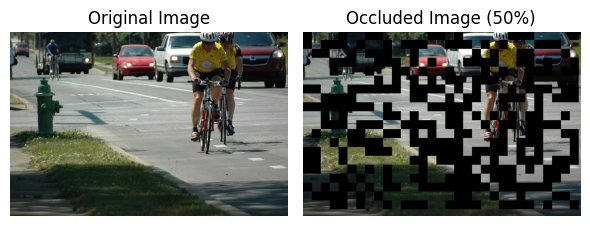

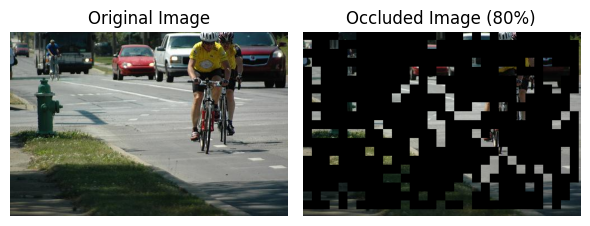

In [ ]:
path = "/kaggle/input/captioning/test/test_8.jpg"
image = Image.open(path).convert("RGB")
img = np.array(image)

img1 = occlude_image(img, 10)
img2 = occlude_image(img, 50)
img3 = occlude_image(img, 80)

visualize_occlusion(img, img1, 10)
visualize_occlusion(img, img2, 50)
visualize_occlusion(img, img3, 80)

In [ ]:
import os
import re
import pandas as pd
from glob import glob
from PIL import Image
import numpy as np

def extract_number(path):
    filename = os.path.basename(path)
    match = re.search(r"(\d+)", filename)
    return int(match.group(1)) if match else -1

test_image_folder = "/kaggle/input/captioning/test/"
image_paths = sorted(glob(os.path.join(test_image_folder, "*.jpg")), key=extract_number)
total_images = len(image_paths)

mask_percentages = [10, 50, 80]

for p in mask_percentages:
    results = []
    print(f"Processing images with {p}% occlusion...")

    for i, image_path in enumerate(image_paths):
        filename = os.path.basename(image_path).split(".")[0]

        image = Image.open(image_path).convert("RGB")
        img_np = np.array(image)

        occluded = occlude_image(img_np, p)
        caption = generate_caption(occluded, model, feature_extractor, device)

        results.append({"filename": filename, "caption": caption})

        if i % 100 == 0:
            print(f"[{i + 1}/{total_images}] {p}% occlusion - Processed: {filename}")

    df = pd.DataFrame(results)
    output_csv_path = f"/kaggle/working/captions-custom-{p}.csv"
    df.to_csv(output_csv_path, index=False)
    print(f"Completed {p}% masking. Captions saved to {output_csv_path}")


In [ ]:
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
!pip install --upgrade nltk

In [ ]:
from nltk.translate.meteor_score import meteor_score

import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

#### **Evaluation**

In [ ]:
def evaluate_on_occluded_images(model, dataloader, device, occlusion_levels, feature_extractor):
    """
    Evaluate image captioning model on different levels of image occlusion.

    Args:
        model (nn.Module): Image captioning model.
        dataloader (DataLoader): Test dataloader with raw_mode=True.
        device (str): 'cuda' or 'cpu'.
        occlusion_levels (list): List of occlusion percentages.

    Returns:
        dict: Dictionary of metric results for each occlusion level.
    """
    model.eval()
    model.to(device)
    results_by_occlusion = {}

    for p in occlusion_levels:
        print(f"\nEvaluating at {p}% occlusion...")
        bleu_scores, meteor_scores, rouge_l_scores = [], [], []
        scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
        smooth_fn = SmoothingFunction().method1
        total_examples = 0
        successful_evaluations = 0

        with torch.no_grad():
            for batch in tqdm(dataloader, desc=f"Occlusion {p}%"):
                img_paths, captions = batch
                # print(len(img_paths))
                # print(type(img_paths))
                # print("+++++++++++")
                # print(img_paths)

                if not isinstance(img_paths, list):
                    img_paths = list(img_paths)
                    captions = list(captions)

                try:
                    predictions = []

                    # Process each image in the batch
                    for img_path in img_paths:
                        # Load image
                        # print(img_path, end = '\n', sep = '\n')
                        image = Image.open(img_path).convert("RGB")
                        img_np = np.array(image)

                        # Apply occlusion
                        occluded_img = occlude_image(img_np, p)

                        # Generate caption using your function
                        caption = generate_caption(occluded_img, model, feature_extractor, device)
                        predictions.append(caption)

                    # Process predictions
                    decoded_preds = []
                    for pred in predictions:
                        if isinstance(pred, torch.Tensor):
                            pred = pred.cpu().numpy().tolist()
                        if isinstance(pred, list) and (
                            isinstance(pred[0], int) or isinstance(pred[0], np.integer)
                        ):
                            pred = " ".join([str(token) for token in pred])
                        decoded_preds.append(pred)

                    references = captions

                    for ref, pred in zip(references, decoded_preds):
                        total_examples += 1
                        try:
                            ref = str(ref).strip()
                            pred = str(pred).strip()
                            ref_tokens = ref.split()
                            pred_tokens = pred.split()

                            if not ref_tokens or not pred_tokens:
                                continue

                            bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth_fn)
                            meteor = meteor_score([ref_tokens], pred_tokens)
                            rouge = scorer.score(ref, pred)["rougeL"].fmeasure

                            bleu_scores.append(bleu)
                            meteor_scores.append(meteor)
                            rouge_l_scores.append(rouge)
                            successful_evaluations += 1

                        except Exception as e:
                            print(f"Error processing prediction: {e}")
                            continue

                except Exception as e:
                    print(f"Error processing batch: {e}")
                    continue

        if successful_evaluations > 0:
            results_by_occlusion[p] = {
                "BLEU": sum(bleu_scores) / len(bleu_scores),
                "METEOR": sum(meteor_scores) / len(meteor_scores),
                "ROUGE-L": sum(rouge_l_scores) / len(rouge_l_scores),
                "Success_Rate": successful_evaluations / total_examples if total_examples > 0 else 0.0
            }
            print(f"Evaluated {successful_evaluations}/{total_examples} examples successfully at {p}% occlusion.")
        else:
            results_by_occlusion[p] = {"BLEU": 0.0, "METEOR": 0.0, "ROUGE-L": 0.0, "Success_Rate": 0.0}
            print(f"No successful evaluations at {p}% occlusion.")

    return results_by_occlusion


In [ ]:
#download WordNet corpus manually as METEOR couldn't be downloaded on kaggle.
import nltk
import os
import zipfile

nltk_data_dir = "/kaggle/working/nltk_data"

os.makedirs(nltk_data_dir, exist_ok=True)

nltk.download("wordnet", download_dir=nltk_data_dir)
nltk.download("omw-1.4", download_dir=nltk_data_dir)

nltk.data.path.append(nltk_data_dir)

wordnet_zip_path = os.path.join(nltk_data_dir, 'corpora', 'wordnet.zip')
wordnet_extract_path = os.path.join(nltk_data_dir, 'corpora', 'wordnet')

if os.path.exists(wordnet_zip_path):
    print(f"Unzipping {wordnet_zip_path}...")
    with zipfile.ZipFile(wordnet_zip_path, 'r') as zip_ref:
        zip_ref.extractall(os.path.join(nltk_data_dir, 'corpora'))
    print(f"WordNet unzipped to {wordnet_extract_path}")

if os.path.exists(wordnet_extract_path):
    print("WordNet corpus is ready!")
else:
    print("WordNet corpus not found. Please check the download.")

[nltk_data] Downloading package wordnet to
[nltk_data]     /kaggle/working/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /kaggle/working/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Unzipping /kaggle/working/nltk_data/corpora/wordnet.zip...
WordNet unzipped to /kaggle/working/nltk_data/corpora/wordnet
WordNet corpus is ready!


In [ ]:
occlusion_levels = [0, 10]

results = evaluate_on_occluded_images(
    model,
    test_loader,
    device,
    occlusion_levels,
    feature_extractor,
)

for level, metrics in results.items():
    print(f"\nOcclusion level {level}%:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")



Evaluating at 0% occlusion...


Occlusion 0%: 100%|██████████| 116/116 [06:50<00:00,  3.54s/it]


Evaluated 928/928 examples successfully at 0% occlusion.

Evaluating at 10% occlusion...


Occlusion 10%: 100%|██████████| 116/116 [06:36<00:00,  3.42s/it]

Evaluated 928/928 examples successfully at 10% occlusion.

Occlusion level 0%:
  BLEU: 0.0290
  METEOR: 0.1807
  ROUGE-L: 0.2597
  Success_Rate: 1.0000

Occlusion level 10%:
  BLEU: 0.0285
  METEOR: 0.1781
  ROUGE-L: 0.2571
  Success_Rate: 1.0000


In [ ]:
occlusion_levels = [50, 80]

results = evaluate_on_occluded_images(
    model,
    test_loader,
    device,
    occlusion_levels,
    feature_extractor,
)

for level, metrics in results.items():
    print(f"\nOcclusion level {level}%:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")



Evaluating at 50% occlusion...


Occlusion 50%: 100%|██████████| 116/116 [06:33<00:00,  3.40s/it]


Evaluated 928/928 examples successfully at 50% occlusion.

Evaluating at 80% occlusion...


Occlusion 80%: 100%|██████████| 116/116 [06:43<00:00,  3.48s/it]

Evaluated 928/928 examples successfully at 80% occlusion.

Occlusion level 50%:
  BLEU: 0.0214
  METEOR: 0.1595
  ROUGE-L: 0.2336
  Success_Rate: 1.0000

Occlusion level 80%:
  BLEU: 0.0205
  METEOR: 0.1576
  ROUGE-L: 0.2270
  Success_Rate: 1.0000


In [10]:
from nltk.translate.meteor_score import meteor_score

In [5]:

'''
Function: performance_metrics
    Calculates and visualizes various evaluation metrics for comparing generated captions (hypotheses)
    with ground truth captions (references).

    The function computes BLEU, ROUGE-L, BERTScore and METEOR

Parameters:
    hypotheses (list): Generated captions
    references (list): Ground truth captions
    csv_path (str): Path to save the per-caption scores

Returns:
    dict: Dictionary containing average scores for all evaluation metrics

Outputs:
    - Saves detailed per-caption scores to a CSV file
    - Displays plots showing the distribution of scores across all captions
    - Prints aggregate metrics
'''

def performance_metrics(hypotheses, references, csv_path="caption_scores.csv"):
    hypotheses = [str(h).strip() if isinstance(h, (str, float)) else "" for h in hypotheses]
    references = [str(r).strip() if isinstance(r, (str, float)) else "" for r in references]

    smooth_fn = SmoothingFunction().method1

    sentence_bleu_scores = []
    rouge_l_scores = []
    bert_f1_scores = []
    meteor_scores_list = []
    rows = []

    rouge_evaluator = Rouge(metrics=["rouge-l"])
    _, _, bert_f1 = score(hypotheses, references, lang="en", verbose=False)
    bert_f1 = bert_f1.tolist()
    n = len(hypotheses)

    print("\n--- Caption Evaluation ---\n")

    for idx, (hypothesis, reference) in enumerate(zip(hypotheses, references)):
        if not hypothesis or not reference:
            bleu = rouge = meteor = 0
        else:
            bleu = sentence_bleu([reference.split()], hypothesis.split(), smoothing_function=smooth_fn)
            rouge = rouge_evaluator.get_scores([hypothesis], [reference])[0]["rouge-l"]["f"]
            meteor = meteor_score([reference.split()], hypothesis.split())

        sentence_bleu_scores.append(bleu)
        rouge_l_scores.append(rouge)
        meteor_scores_list.append(meteor)

        row = {
            "Index": idx + 1,
            "Hypothesis": hypothesis,
            "Reference": reference,
            "Sentence BLEU": bleu,
            "ROUGE-L F1": rouge,
            "BERTScore F1": bert_f1[idx],
            "METEOR": meteor
        }
        rows.append(row)
        #print(f"[{idx+1}/{n}] BLEU: {bleu:.4f}, ROUGE-L: {rouge:.4f}, BERT: {bert_f1[idx]:.4f}, METEOR: {meteor:.4f}")

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)

    indices = list(range(len(hypotheses)))
    step = max(len(hypotheses) // 20, 1)
    x_ticks = np.arange(0, len(hypotheses), step)

    fig, axs = plt.subplots(2, 2, figsize=(18, 8))

    axs[0, 0].plot(indices, sentence_bleu_scores, color='skyblue', linewidth=0.8)
    axs[0, 0].set_title("Sentence BLEU Score")
    axs[0, 0].set_xticks(x_ticks)
    axs[0, 0].set_xlabel("Caption Index")
    axs[0, 0].set_ylabel("Score")

    axs[0, 1].plot(indices, rouge_l_scores, color='salmon', linewidth=0.8)
    axs[0, 1].set_title("ROUGE-L F1 Score")
    axs[0, 1].set_xticks(x_ticks)
    axs[0, 1].set_xlabel("Caption Index")

    axs[1, 0].plot(indices, bert_f1, color='lightgreen', linewidth=0.8)
    axs[1, 0].set_title("BERTScore F1")
    axs[1, 0].set_xticks(x_ticks)
    axs[1, 0].set_xlabel("Caption Index")

    axs[1, 1].plot(indices, meteor_scores_list, color='violet', linewidth=0.8)
    axs[1, 1].set_title("METEOR Score")
    axs[1, 1].set_xticks(x_ticks)
    axs[1, 1].set_xlabel("Caption Index")

    plt.tight_layout()
    plt.show()

    results = {
        "Sentence BLEU Score": sum(sentence_bleu_scores) / len(sentence_bleu_scores) if sentence_bleu_scores else 0,
        "Corpus BLEU Score": corpus_bleu([[r.split()] for r in references if r], [c.split() for c in hypotheses if c]) if any(references) else 0,
        "Average ROUGE-L F1": sum(rouge_l_scores) / len(rouge_l_scores) if rouge_l_scores else 0,
        "Average BERTScore F1": sum(bert_f1) / len(bert_f1) if bert_f1 else 0,
        "Average METEOR Score": sum(meteor_scores_list) / len(meteor_scores_list) if meteor_scores_list else 0
    }

    return results

In [6]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

928
928
A red and white bus is driving down the street. There is a large white building behind the bus.  There are trees in front of the building.
A large building with bars on the windows in front of it. There is people walking in front of the building. There is a street in front of the building with many cars on it. 


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Caption Evaluation ---



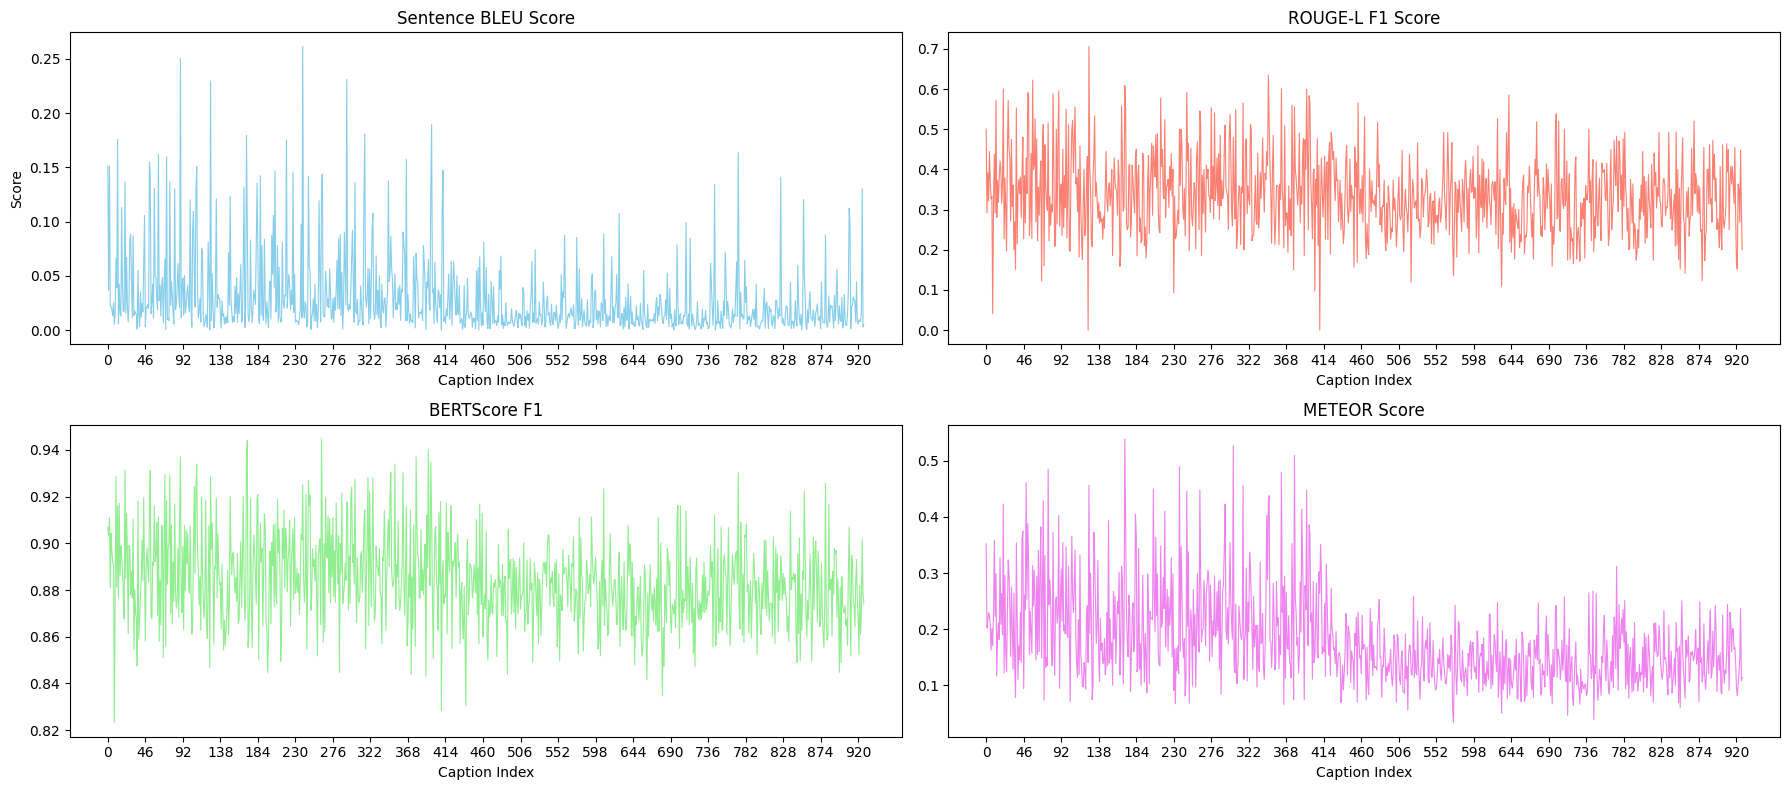

Performance Metrics:
Sentence BLEU Score: 0.0289
Corpus BLEU Score: 0.0280
Average ROUGE-L F1: 0.3358
Average BERTScore F1: 0.8838
Average METEOR Score: 0.1791


In [11]:
hypotheses_file_path = '/content/captions-custom-10.csv'
references_file_path = '/content/test.csv'

df = pd.read_csv(hypotheses_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
hypotheses = df['caption'].tolist()

df = pd.read_csv(references_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
references = df['caption'].tolist()

print(len(hypotheses))
print(len(references))
print(hypotheses[0])
print(references[0])

csv_path = 'custom-scores-10.csv'
metrics = performance_metrics(hypotheses, references, csv_path)
print("Performance Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

928
928
The image is of a train on the tracks. The train is red and white. There is a large white building behind the train. 
A large building with bars on the windows in front of it. There is people walking in front of the building. There is a street in front of the building with many cars on it. 


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Caption Evaluation ---



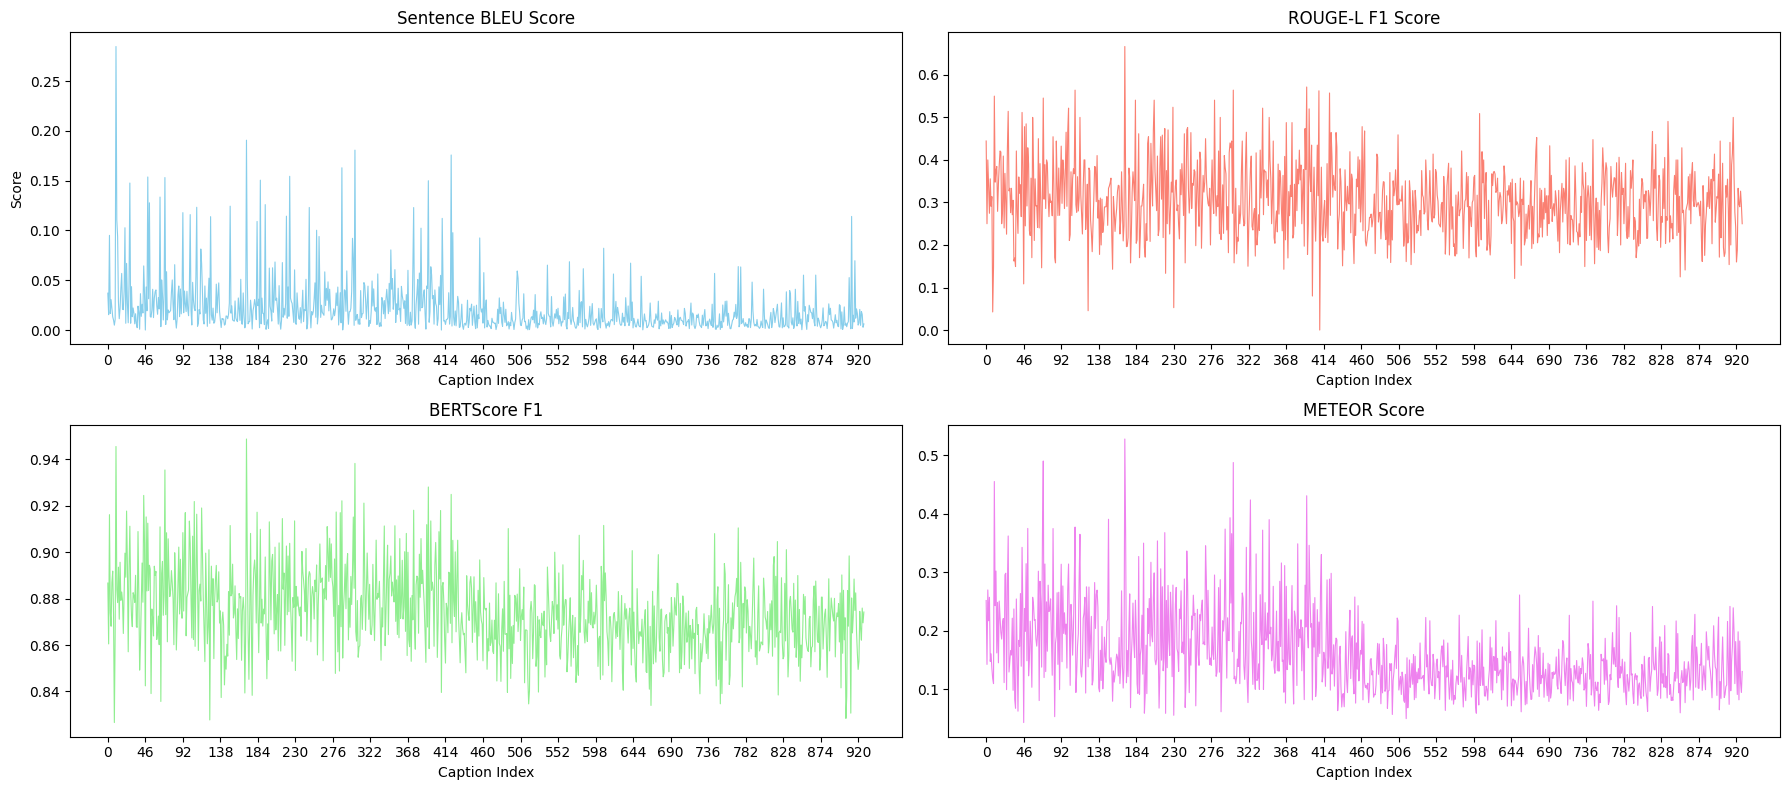

Performance Metrics:
Sentence BLEU Score: 0.0216
Corpus BLEU Score: 0.0196
Average ROUGE-L F1: 0.3050
Average BERTScore F1: 0.8744
Average METEOR Score: 0.1599


In [12]:
hypotheses_file_path = '/content/captions-custom-50.csv'
references_file_path = '/content/test.csv'

df = pd.read_csv(hypotheses_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
hypotheses = df['caption'].tolist()

df = pd.read_csv(references_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
references = df['caption'].tolist()

print(len(hypotheses))
print(len(references))
print(hypotheses[0])
print(references[0])

csv_path = 'custom-scores-50.csv'
metrics = performance_metrics(hypotheses, references, csv_path)
print("Performance Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

928
928
A wooden bench is sitting on a bench. There is a black and white picture hanging on the wall. The bench has a red and black handle. 
A large building with bars on the windows in front of it. There is people walking in front of the building. There is a street in front of the building with many cars on it. 


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Caption Evaluation ---



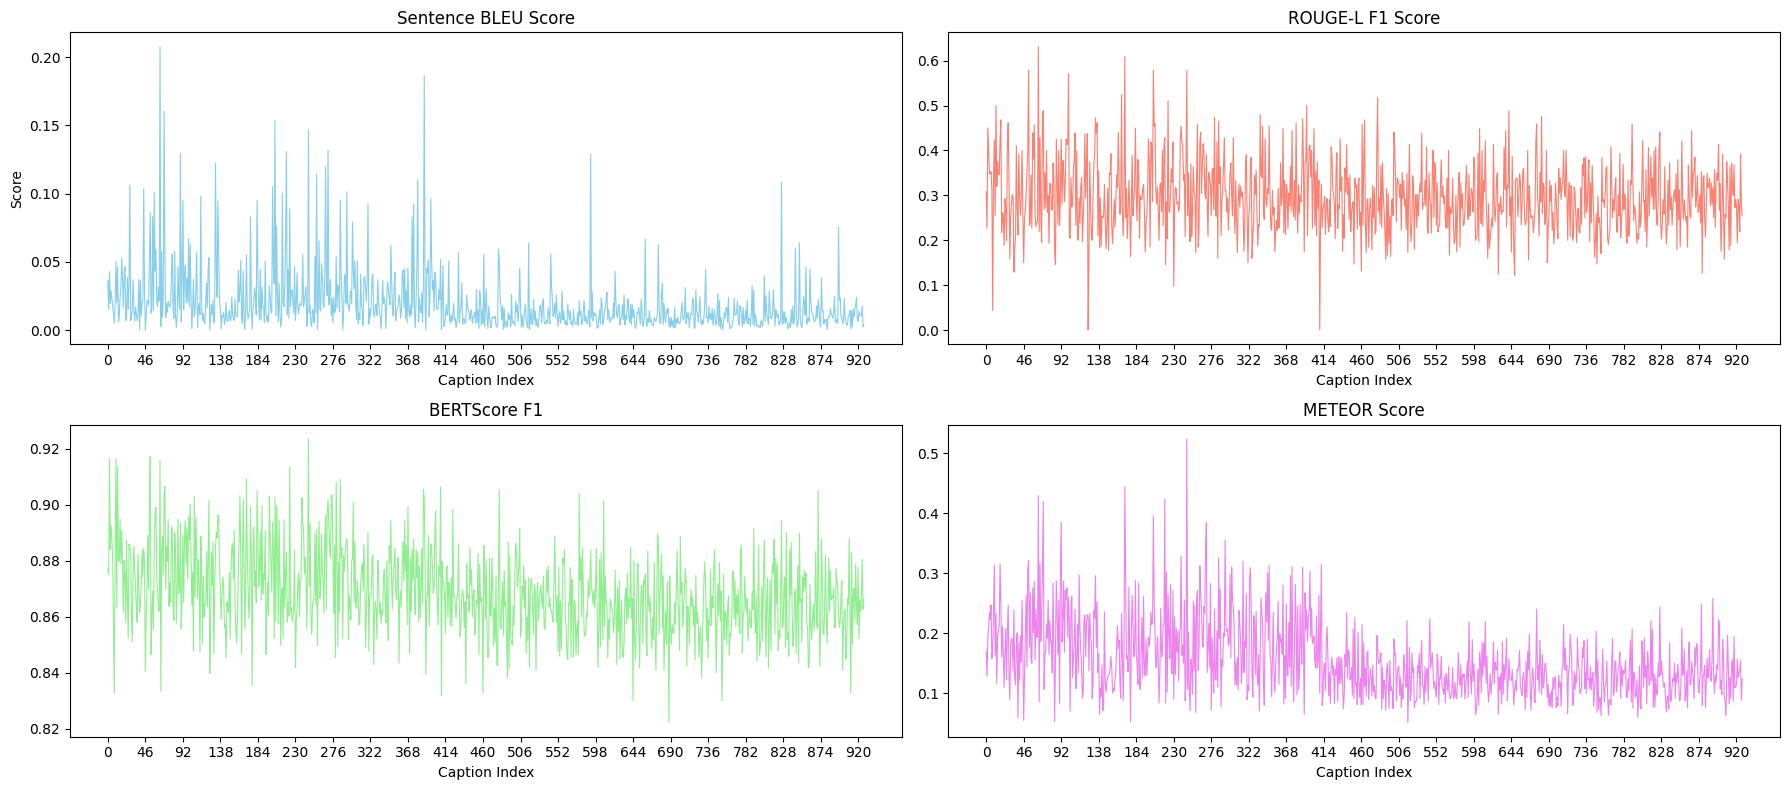

Performance Metrics:
Sentence BLEU Score: 0.0199
Corpus BLEU Score: 0.0175
Average ROUGE-L F1: 0.2966
Average BERTScore F1: 0.8688
Average METEOR Score: 0.1555


In [13]:
hypotheses_file_path = '/content/captions-custom-80.csv'
references_file_path = '/content/test.csv'

df = pd.read_csv(hypotheses_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
hypotheses = df['caption'].tolist()

df = pd.read_csv(references_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
references = df['caption'].tolist()

print(len(hypotheses))
print(len(references))
print(hypotheses[0])
print(references[0])

csv_path = 'custom-scores-80.csv'
metrics = performance_metrics(hypotheses, references, csv_path)
print("Performance Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

928
928
This is an image of a street. The street is very busy with traffic. There is a large white building with a clock on the top of it. This clock has a white face and black numbers. 
A large building with bars on the windows in front of it. There is people walking in front of the building. There is a street in front of the building with many cars on it. 


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Caption Evaluation ---



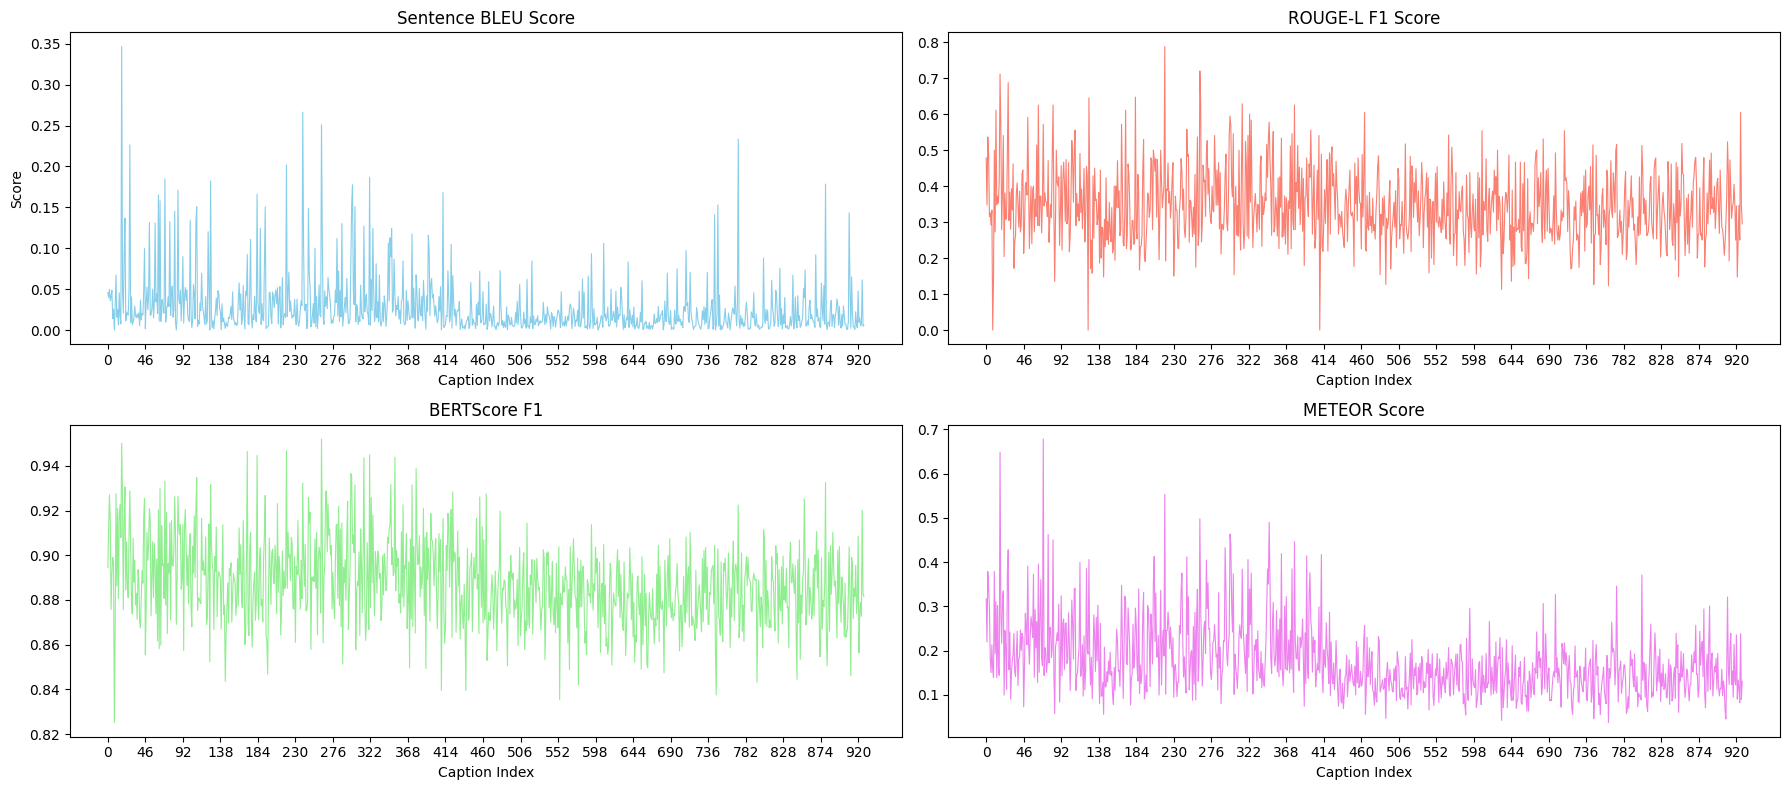

Performance Metrics:
Sentence BLEU Score: 0.0277
Corpus BLEU Score: 0.0266
Average ROUGE-L F1: 0.3450
Average BERTScore F1: 0.8875
Average METEOR Score: 0.1764


In [14]:
hypotheses_file_path = '/content/captions-custom.csv'
references_file_path = '/content/test.csv'

df = pd.read_csv(hypotheses_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
hypotheses = df['caption'].tolist()

df = pd.read_csv(references_file_path, delimiter=',', names=['filename', 'caption'], skiprows=1)
references = df['caption'].tolist()

print(len(hypotheses))
print(len(references))
print(hypotheses[0])
print(references[0])

csv_path = 'custom-scores-0.csv'
metrics = performance_metrics(hypotheses, references, csv_path)
print("Performance Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")